# STEP 1: PROBLEM UNDERSTANDING

## 1. Problem Type
- **Task:** Multi-class Classification (Hate Speech Detection).
- **Model:** PhoBERT-base-v2 (Context-Aware).

## 2. Input & Output
- **Input:** Sequence Pair: `[CLS] Context [SEP] Comment [SEP]`
- **Output:** 3 Classes:
  - 0: Clean
  - 1: Offensive (Chửi thề, không thù ghét)
  - 2: Hate Speech (Tấn công bản sắc, kích động bạo lực)

## 3. Objective
- Giải quyết vấn đề mất ngữ cảnh (Context Dependency) của model cũ.
- Xử lý mất cân bằng dữ liệu (Imbalanced Data) với Weighted Loss.

# STEP 2: DATA UNDERSTANDING

## Objective
Khám phá dữ liệu để phát hiện các vấn đề tiềm ẩn ảnh hưởng đến model PhoBERT:
1. **Missing Values:** Kiểm tra dữ liệu bị khuyết.
2. **Class Imbalance:** Kiểm tra độ lệch giữa các nhãn (0, 1, 2).
3. **Outliers/Noise:** Phát hiện các câu quá ngắn (vô nghĩa) hoặc quá dài (gây tràn bộ nhớ).
4. **Data Quality:** Kiểm tra dữ liệu trùng lặp.


In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

# 1. Load data
df = pd.read_csv("training_data_final_merged.csv")
print("=== DATASET INFO ===")
print(f"Total rows: {len(df)}")
# print(f"Total columns: {len(df.columns)}")
# print(f"Coulmns: {df.columns}")
print(f"Columns: {df.columns.tolist()}")

# 2. Check for missing values
print("\n=== MISSING VALUES ===")
print(df.isnull().sum())
missing_notes = df['note'].isnull().sum()
total_rows = len(df)
print(f"Missing values in 'note' {missing_notes}/{total_rows} ({missing_notes/total_rows:.1%}%)")
# 3. Check for duplicates
print("\n=== DUPLICATES ===")
duplicates = df.duplicated(subset = ['input_text']).sum()
print(f"Total duplicate rows: {duplicates}")

# Show samples data
print("\n=== SAMPLE DATA ===")
df.head()

# 4. Filter data cleaning
df_clean = df[['input_text', 'label']].copy()
# Exploratory Data Analysis (EDA) ready dataset
print("\n Dataset ready for EDA: ", df_clean.shape)

=== DATASET INFO ===
Total rows: 1127
Columns: ['input_text', 'label', 'note']

=== MISSING VALUES ===
input_text       0
label            0
note          1083
dtype: int64
Missing values in 'note' 1083/1127 (96.1%%)

=== DUPLICATES ===
Total duplicate rows: 0

=== SAMPLE DATA ===

 Dataset ready for EDA:  (1127, 2)


## 2. Kiểm tra nhãn mất cân bằng (Imbalanced data)


=== LABEL COUNTS ===
label
0    467
1    289
2    371
Name: count, dtype: int64

=== LABEL PERCENTAGES ===
label
0    41.437445
1    25.643301
2    32.919255
Name: proportion, dtype: float64
-0.4
0.6
1.6


C:\Users\tran thien\AppData\Local\Temp\ipykernel_2860\543022972.py:13: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  ax = sns.countplot(x='label', data=df, palette='viridis')


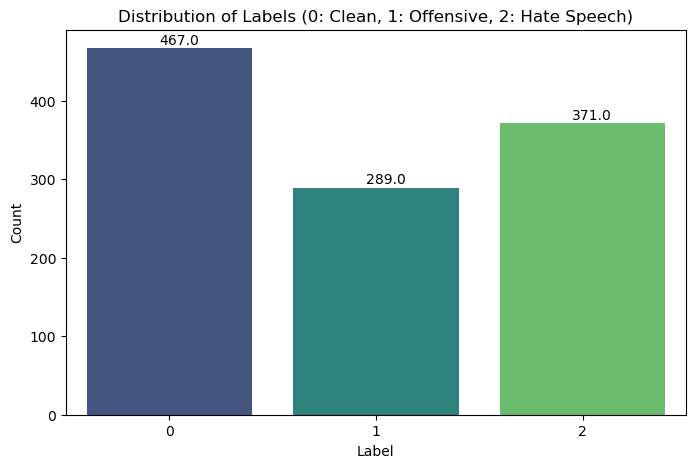

In [2]:
# Tính số lượng từng nhãn
label_counts = df_clean['label'].value_counts().sort_index()
print("\n=== LABEL COUNTS ===")
print(label_counts)

# Tính tỉ lệ %
label_percentages = df_clean['label'].value_counts(normalize = True).sort_index() * 100
print("\n=== LABEL PERCENTAGES ===")
print(label_percentages)

# Vẽ biểu đồ
plt.figure(figsize=(8, 5))
ax = sns.countplot(x='label', data=df, palette='viridis')
plt.title('Distribution of Labels (0: Clean, 1: Offensive, 2: Hate Speech)')
plt.xlabel('Label')
plt.ylabel('Count')

for p in ax.patches:
    ax.annotate(f'{p.get_height()}', (p.get_x() + 0.35, p.get_height() + 5))
    print(p.get_x())
plt.show()

=== WORD CLOUD FOR LABEL 1 (OFFENSIVE) ===


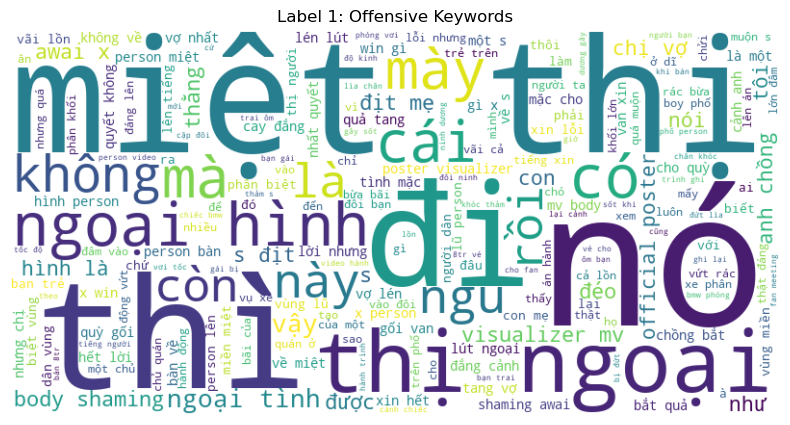

=== WORD CLOUD FOR LABEL 2 (HATE SPEECH) ===


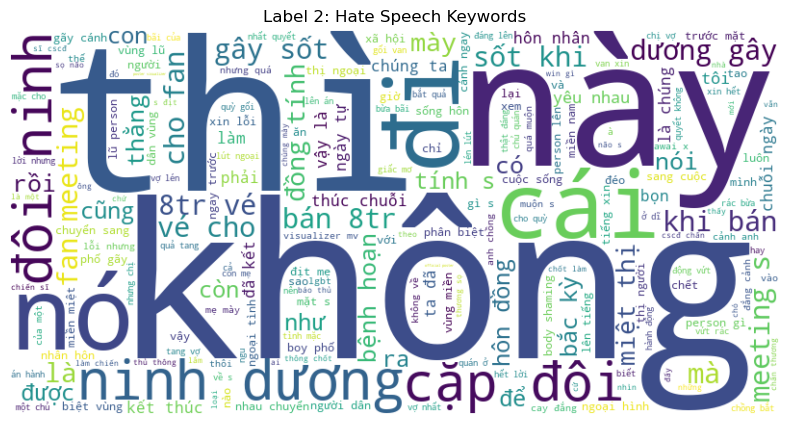

In [5]:
from wordcloud import WordCloud

# Hàm vẽ WordCloud
def plot_wordcloud(text_data, title):
    # Ghép toàn bộ text lại
    text = " ".join(str(t) for t in text_data)
    # Tạo wordcloud
    wc = WordCloud(width=800, height=400, background_color='white', colormap='viridis').generate(text)
    
    plt.figure(figsize=(10, 5))
    plt.imshow(wc, interpolation='bilinear')
    plt.axis('off')
    plt.title(title)
    plt.show()

# Vẽ cho từng nhãn
print("=== WORD CLOUD FOR LABEL 1 (OFFENSIVE) ===")
plot_wordcloud(df[df['label']==1]['input_text'], "Label 1: Offensive Keywords")

print("=== WORD CLOUD FOR LABEL 2 (HATE SPEECH) ===")
plot_wordcloud(df[df['label']==2]['input_text'], "Label 2: Hate Speech Keywords")

In [4]:
!pip install wordcloud